# Exploración de fuentes verificadas — Turismo-BCN

Primer vistazo real a los datos descargados en `data/raw/` durante la Fase 1 (ver `docs/roadmap.md` y `docs/architecture.md`). Objetivo: ver qué tenemos de verdad, no solo confiar en el nombre del dataset.

In [1]:
import pandas as pd
import geopandas as gpd
import json
from pathlib import Path

RAW = Path('../../data/raw')
pd.set_option('display.max_columns', None)

## 1. VUT — Open Data BCN (ciudad)

In [2]:
vut = pd.read_csv(RAW / 'vut' / 'opendata_bcn_hut_2016-2026Q1.csv')
print(vut.shape)
vut.head()

(10718, 21)


,N_EXPEDIENT,CODI_DISTRICTE,NOM_DISTRICTE,CODI_BARRI,NOM_BARRI,TIPUS_CARRER,CARRER,TIPUS_NUM,NUM1,LLETRA1,NUM2,LLETRA2,BLOC,PORTAL,ESCALA,PIS,PORTA,NUMERO_REGISTRE_GENERALITAT,NUMERO_PLACES,LONGITUD_X,LATITUD_Y
0,01-2009-0354,1,CIUTAT VELLA,1.0,el Raval,Carrer,SANT JOSEP ORIOL,1,19,NaN,NaN,NaN,NaN,NaN,NaN,01,1,HUTB-002222,3.0,2.170172,41.378445
1,01-2011-0123,1,CIUTAT VELLA,4.0,Sant Pere Santa Caterina i la Ribera,Carrer,AGULLERS,2,22,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,HUTB-003654,3.0,2.182004,41.382884
2,01-2011-0137,1,CIUTAT VELLA,2.0,el Barri Gòtic,Carrer,ROCA,2,8,NaN,NaN,NaN,NaN,NaN,NaN,01,2,HUTB-001678,3.0,2.173086,41.382224
3,01-2011-0152,1,CIUTAT VELLA,4.0,Sant Pere Santa Caterina i la Ribera,Carrer,AGULLERS,2,22,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,HUTB-003650,3.0,2.182004,41.382884
4,01-2011-0157,1,CIUTAT VELLA,4.0,Sant Pere Santa Caterina i la Ribera,Plaça,OLLES,1,9,B,NaN,NaN,NaN,NaN,NaN,01,2,HUTB-002534,9.0,2.183305,41.383685


In [3]:
# Licencias VUT activas por distrito
vut['NOM_DISTRICTE'].value_counts()

NOM_DISTRICTE
L'EIXAMPLE             4897
SANTS-MONTJUÏC         1304
SANT MARTI             1232
GRACIA                 1129
CIUTAT VELLA            843
SARRIA-SANT GERVASI     662
LES CORTS               264
HORTA-GUINARDÓ          252
SANT ANDREU              94
NOU BARRIS               41
Name: count, dtype: int64

## 2. Hoteles — Open Data BCN (ciudad, snapshot)

In [4]:
hoteles = pd.read_csv(RAW / 'hoteles' / 'opendata_bcn_hotels_snapshot.csv')
print(hoteles.shape)
hoteles[['name', 'addresses_district_name', 'addresses_neighborhood_name']].drop_duplicates().head(10)

(446, 40)


,name,addresses_district_name,addresses_neighborhood_name
0,Hotel chic&basic Born Boutique - HB-004452,Ciutat Vella,"Sant Pere, Santa Caterina i la Ribera"
1,Hotel Prisma - HB-000114,Les Corts,les Corts
2,Hotel Ofelias - HB-004547,Eixample,la Nova Esquerra de l'Eixample
3,Hotel Praktik Vinoteca - HB-004628,Eixample,l'Antiga Esquerra de l'Eixample
4,Hotel Paseo de Gracia - HB-003252,Eixample,la Dreta de l'Eixample
5,Hotel NH Barcelona Ramblas - HB-004369,Ciutat Vella,el Raval
6,Hotel Grupotel Gran Via 678 - HB-004421,Eixample,la Dreta de l'Eixample
7,Hotel Duquesa de Cardona - HB-004147,Ciutat Vella,el Barri Gòtic
8,Hotel HCC Montblanc - HB-004088,Ciutat Vella,el Barri Gòtic
9,Hotel America - HB-004153,Eixample,l'Antiga Esquerra de l'Eixample


## 3. Registre de Turisme de Catalunya — provincia de Barcelona completa (27.180 registros)

In [5]:
hut = pd.read_csv(RAW / 'registre_turisme' / 'hut_provincia_barcelona.csv')
hoteles_at = pd.read_csv(RAW / 'registre_turisme' / 'hoteles_y_apartaments_turistics_provincia_barcelona.csv')
print('HUT:', hut.shape, '| Hoteles+AT:', hoteles_at.shape)
hoteles_at[['tipus_establiment', 'r_tol', 'municipi', 'ra_social_del_titular', 'cif', 'total_places', 'total_estances']].head(10)

HUT: (23975, 25) | Hoteles+AT: (1562, 26)


,tipus_establiment,r_tol,municipi,ra_social_del_titular,cif,total_places,total_estances
0,Apartaments Turístics,Atenea Calabria,Barcelona,"TEXFIL GANDUXER ALUM, SA",A08115669,160,80
1,Apartaments Turístics,Voramar,Castelldefels,"CASTELLISCON, SL",B63470942,36,18
2,Apartaments Turístics,Gutenberg,Barcelona,"APARTAMENTOS GUTENBERG, SA",A08433989,170,85
3,Apartaments Turístics,Montserrat,Sitges,No aplica,No aplica,12,6
4,Apartaments Turístics,Silver,Barcelona,"PROYECTOS E INMUEBLES, S. A",A08139859,98,49
5,Apartaments Turístics,Castellmar,Castelldefels,"MARFINA APARTAMENTOS, SL",B61933511,22,10
6,Apartaments Turístics,Marfina,Castelldefels,"MARFINA APARTAMENTOS, SL",B61933511,47,22
7,Apartaments Turístics,Porta Coeli,Castelldefels,"MARFINA APARTAMENTOS, SL",B61933511,34,15
8,Apartaments Turístics,SENATOR BARCELONA APARTMENTS,Barcelona,APARTHOTEL SENATOR SA,A08900334,36,18
9,Apartaments Turístics,Marítim,Castelldefels,"CASELLSOL, SL",B58323106,52,20


## 4. Bares/restaurantes y hoteles de la provincia — Diputació de Barcelona

In [6]:
import urllib.request

# Filtro correcto: va en la ruta, no en query string (ver docs/architecture.md).
# 08192 = Santpedor (confirmado que tiene datos). Ojo: ciudades grandes como
# Barcelona (08019) o Badalona (08015) no participan en este censo, dan 0 registros.
url = 'https://do.diba.cat/api/dataset/establiments/camp-rel_municipi/08192/format/json'
with urllib.request.urlopen(url) as resp:
    diba_raw = json.load(resp)
diba = pd.json_normalize(diba_raw['elements'])
print(diba.shape, '| municipio filtrado: Santpedor (08192)')
diba[['nom_comercial', 'descripcio_activitat', 'rao_social_nom', 'rao_social_nif', 'adreca.nom_municipi']].head(10)

(323, 37) | municipio filtrado: Santpedor (08192)


,nom_comercial,descripcio_activitat,rao_social_nom,rao_social_nif,adreca.nom_municipi
0,LA CAIXA,Oficina bancària,CAIXA D'ESTALVIS I PENSIONS DE BARCELONA,G58899998,SANTPEDOR
1,GESTORIA JORBA,Gestor administratiu,GESTORIA ASSESSORIA JORBA SL,B59949453,SANTPEDOR
2,MARTISA SOLDADURA S.L.,Taller de soldadura de peces metàl·liques,MARTISA SOLDADURA S.L.,B61866612,SANTPEDOR
3,GRANJA CAN AUBREDA,RAMDERIA INTENSIVA DE BESTIAR PORCÍ,"CATALANA DE PIENSOS, S.A.",B08987208,SANTPEDOR
4,,Emmagatzematge materials i productes per a la ...,CONSAN SA,A58230574,SANTPEDOR
5,,Estampació i soldadura,GABERMETALL SL,B60573623,SANTPEDOR
6,GRANJA CASA LLUSSÀ,"Explotació ramadera (boví, avícola, porcí, cun...",,,Santpedor
7,MARTI AGRÍCOLA,Activitat de magatzem i venda al major i detal...,"MARTI FABRES, S.L.",B61025235,SANTPEDOR
8,,APARCAMENT VEHICLES,"PROGUIVI, S.L.",B61966362,SANTPEDOR
9,,APARCAMENT VEHICLES,"CONSTRUCCIONES EFMA, S.L.",B60793320,SANTPEDOR


In [7]:
# Filtrar bares y restaurantes por texto libre (no hay codigo estable, ver architecture.md)
patron = r'bar|restaurant'
bares_restaurantes = diba[diba['descripcio_activitat'].str.contains(patron, case=False, na=False)]
print('bares/restaurantes en esta muestra de 1000:', len(bares_restaurantes))
bares_restaurantes[['nom_comercial', 'descripcio_activitat', 'adreca.nom_municipi']].head(10)

bares/restaurantes en esta muestra de 1000: 24


,nom_comercial,descripcio_activitat,adreca.nom_municipi
15,TESI RESTAURANT,Restaurant,SANTPEDOR
69,RESTAURANT MIRADOR DE MONTSERRAT,Restaurant.,SANTPEDOR
87,EL FAROLILLO,BAR,SANTPEDOR
119,EL TERRER 1834,BOTIGA AMB UN ESPAI DEDICAT A BAR I DEGUSTACIO...,Santpedor
123,,Bar-Restaurant,SANTPEDOR
140,BAMBÚ,BAR CAFETERIA,SANTPEDOR
144,BAR CANALETAS KEBAB,BAR CAFE,Santpedor
152,CUGA RESTAURANT SL,BAR RESTAURANT AMB SERVEI DE BAR MUSICAL,Santpedor
153,L'ESPAI CAFETERIA,PISTA DE PÀDEL AMB SERVEI DE BAR,Santpedor
154,BAR LA BRASA,Bar,SANTPEDOR


## 5. Oferta anunciada en Airbnb (Inside Airbnb)

In [8]:
airbnb = pd.read_csv(RAW / 'airbnb' / 'insideairbnb_barcelona_2026-06-24_listings.csv')
print(airbnb.shape)
airbnb[['name', 'neighbourhood', 'room_type', 'price', 'license']].head(10)

(15406, 19)


,name,neighbourhood,room_type,price,license
0,Huge flat for 8 people close to Sagrada Familia,la Sagrada Família,Entire home/apt,409.0,Spain - National registration number<br />ESFC...
1,CCIB Forum· Large Balcony · 5 min walk to CCIB,el Besòs i el Maresme,Entire home/apt,388.0,Spain - National registration number<br />ESFC...
2,VIDRE HOME PLAZA REAL on LAS RAMBLAS,el Barri Gòtic,Entire home/apt,397.0,Spain - National registration number<br />ESFC...
3,In front of the beach,la Barceloneta,Private room,43.0,NaN
4,Architect's Loft near Gaudí & Passeig de Gràcia,la Dreta de l'Eixample,Entire home/apt,226.0,Barcelona - Regional registration number<br />...
5,Sagrada Familia area - Còrsega 2,el Camp d'en Grassot i Gràcia Nova,Entire home/apt,NaN,Barcelona - Regional registration number<br />...
6,Charming apartment with fantastic views!,Vallcarca i els Penitents,Entire home/apt,418.0,Barcelona - Regional registration number<br />...
7,Best deals for penthouse near Sagrada Familia!,la Dreta de l'Eixample,Entire home/apt,276.0,Barcelona - Regional registration number<br />...
8,Modernist apartment in the center minim 32 nights,el Raval,Entire home/apt,108.0,Spain - National registration number<br />ESFC...
9,Lugaris Beach Business Apartment,el Poblenou,Entire home/apt,209.0,Barcelona - Regional registration number<br />...


In [9]:
# Cuantos anuncios traen un HUTB parseable en el campo license
con_hutb = airbnb['license'].str.contains('HUTB', case=False, na=False)
print(f"Con HUTB: {con_hutb.sum()} de {len(airbnb)} ({con_hutb.mean():.1%})")
exento = airbnb['license'].str.contains('Exempt', case=False, na=False) & ~con_hutb
print(f"Exento (y sin HUTB): {exento.sum()} ({exento.mean():.1%})")
sin_info = airbnb['license'].isna()
print(f"Sin ninguna info de licencia: {sin_info.sum()} ({sin_info.mean():.1%})")

Con HUTB: 7444 de 15406 (48.3%)
Exento (y sin HUTB): 3674 (23.8%)
Sin ninguna info de licencia: 3156 (20.5%)


## 6. Geometría municipal — ICGC (provincia de Barcelona)

In [10]:
municipios = gpd.read_file(RAW / 'geometria' / 'icgc_municipis_provincia_barcelona.geojson')
print(municipios.shape, municipios.crs)
municipios[['CODIMUNI', 'NOMMUNI', 'NOMCOMAR']].head(10)

(311, 21) EPSG:4326


,CODIMUNI,NOMMUNI,NOMCOMAR
0,080018,Abrera,Baix Llobregat
1,080023,Aguilar de Segarra,Bages
2,080039,Alella,Maresme
3,080044,Alpens,Lluçanès
4,080057,l'Ametlla del Vallès,Vallès Oriental
5,080060,Arenys de Mar,Maresme
6,080076,Arenys de Munt,Maresme
7,080082,Argençola,Anoia
8,080095,Argentona,Maresme
9,080109,Artés,Bages


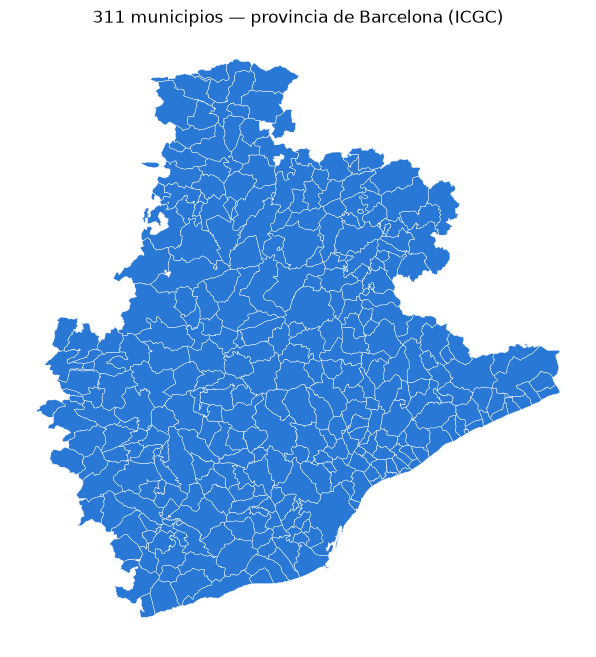

In [11]:
ax = municipios.plot(figsize=(8, 8), edgecolor='white', linewidth=0.3, color='#2a78d6')
ax.set_title(f'{len(municipios)} municipios — provincia de Barcelona (ICGC)')
ax.set_axis_off()

## 7. PEUAT — zonas hoteleras de la ciudad

In [12]:
peuat = gpd.read_file(RAW / 'peuat' / 'peuat_zonas.geojson')
peuat[['ZE', 'AREA']]

,ZE,AREA
0,EXCLO,3547.834837
1,ZE1,1316.179832
2,ZE2,1334.336467
3,ZE3A,272.562045
4,ZE3B,1092.732250
5,ZE3C,850.437775
6,ZE3D,1081.441216
7,ZE3E,474.370862
8,ZE4A,75.773151
9,ZE4B,92.848009


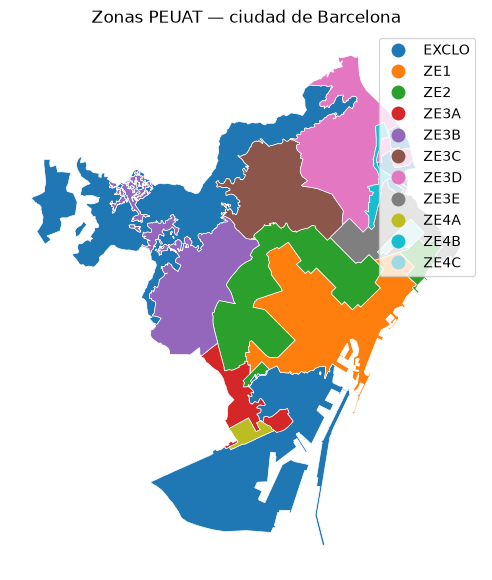

In [13]:
ax = peuat.plot(column='ZE', figsize=(7, 7), legend=True, cmap='tab20', edgecolor='white', linewidth=0.5)
ax.set_title('Zonas PEUAT — ciudad de Barcelona')
ax.set_axis_off()

## Notas de implementación

- **OTB**: resuelto para este informe puntual — los PDF son infografías, no tablas, así que se renderizaron como imagen y se transcribió a mano verificando visualmente (sección 8). Para escalar a todos los meses hace falta automatizarlo (extracción por posición) o repetir la transcripción manual cada vez.
- **Diputació**: resuelto — el filtro por municipio va en la ruta, no en query string: `camp-rel_municipi/<codi>/format/json` (sección 4, ya actualizada). Confirmado que Barcelona ciudad no participa en este censo (usa Open Data BCN).

## 8. OTB — Perfil del turista (Noviembre 2025)

Los PDF de OTB son infografías, no tablas — `pdfplumber.extract_tables()` no las resuelve bien. Se renderizaron las páginas como imagen y se transcribieron los datos verificándolos visualmente (ver `data/raw/otb/pagina4_ciutat.png`, `pagina5_regio.png`, `pagina6_destinacio.png`). El resultado transcrito está en `data/processed/otb_perfil_turista_2025-11.csv`.

In [14]:
otb = pd.read_csv('../../data/processed/otb_perfil_turista_2025-11.csv')
otb

,ambito,catalunya_pct,resta_espanya_pct,resta_europa_pct,resta_mon_pct,estada_mitjana_nits,despesa_estada_per_nit_eur
0,ciutat,1.2,9.6,55.8,33.5,4.3,104.86
1,regio,30.5,27.1,35.0,7.4,2.8,51.61
2,destinacio,12.5,16.4,47.7,23.3,3.8,84.31


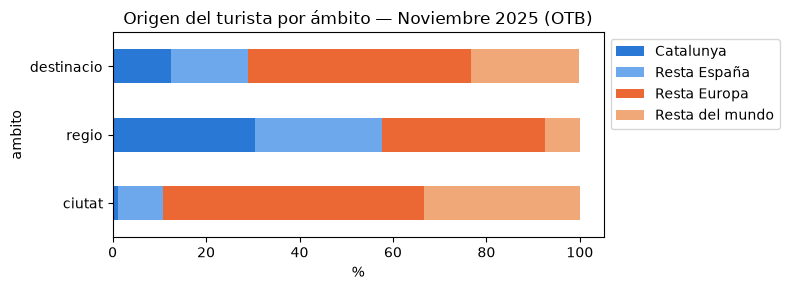

In [15]:
# De donde vienen los turistas, por ambito
import matplotlib.pyplot as plt
cols = ['catalunya_pct', 'resta_espanya_pct', 'resta_europa_pct', 'resta_mon_pct']
labels = ['Catalunya', 'Resta España', 'Resta Europa', 'Resta del mundo']
ax = otb.set_index('ambito')[cols].plot(kind='barh', stacked=True, figsize=(8,3), color=['#2a78d6','#6da7ec','#eb6834','#f0a878'])
ax.legend(labels, bbox_to_anchor=(1,1))
ax.set_xlabel('%')
ax.set_title('Origen del turista por ámbito — Noviembre 2025 (OTB)')
plt.tight_layout()